In [ ]:
import os
import glob
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
from joblib import Parallel, delayed

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np


# === CONFIG ===
source_dir = "/liu1/Son/Projects/TYK2/result_gnina"  # <--- change this to your top-level directory

# === FUNCTION TO COMPUTE DESCRIPTORS ===
def compute_descriptors(sdf_path):
    try:
        suppl = Chem.SDMolSupplier(sdf_path, removeHs=False)
        mol = suppl[0] if suppl and suppl[0] is not None else None
        if mol is None:
            return None

        compound_name = os.path.basename(sdf_path)[:-4]
        
        def safe_get(field):
            try:
                return mol.GetProp(field)
            except:
                return None  # Will appear as NaN in DataFrame

        return {
            'Compounds': compound_name,
            'SMILES': str(safe_get("SMILES")),
            'SID': str(safe_get("SID")),
            'CID': str(safe_get("CID")),
            'NSC': str(safe_get("NSC")),
            'CAS': safe_get("CAS"),
            'MW': round(Descriptors.MolWt(mol),2),
            'logP': round(Crippen.MolLogP(mol),2),
            'HBD': Lipinski.NumHDonors(mol),
            'HBA': Lipinski.NumHAcceptors(mol),
            'TPSA': round(rdMolDescriptors.CalcTPSA(mol),2),
            'NumHeavyAtoms': mol.GetNumHeavyAtoms(),
            'NumRotatableBonds': Lipinski.NumRotatableBonds(mol),
            'Charge': Chem.GetFormalCharge(mol)
        }
    except Exception as e:
        print(f"Error in {sdf_path}: {e}")
        return None
    



sdf_files = glob.glob(os.path.join(source_dir,"all","TYK2","rank1","*.sdf"))
sdf_files
# === RUN JOBS IN PARALLEL ===
results = Parallel(n_jobs=40)(delayed(compute_descriptors)(sdf) for sdf in sdf_files)
results = [r for r in results if r is not None]

# # === OUTPUT ===
output_dir = os.path.join(source_dir,"all","TYK2","Confidence_score")
df = pd.DataFrame(results)
output_csv = os.path.join(output_dir, "TYK2_properties.csv")
df.to_csv(output_csv, index=False)
print(f"Processed {len(df)} molecules. Results saved to: {output_csv}")


In [ ]:
df1 = pd.read_csv("/liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_final.csv")
df2 = pd.read_csv("/liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_properties.csv")
merged_df_final = pd.merge(df1,df2,on="Compounds",how="inner")
merged_df_final.to_csv("/liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_properties_score.csv",index=False)

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_Affinity_TPSA.csv
[  3.24  34.87  54.42  72.71  91.05 110.17 154.27 412.38] [-6.7088 -6.7088 -6.9148 -7.3104 -6.9619 -7.2595 -6.9857 -6.9857] [3.9351 3.9351 4.5899 3.1846 4.4975 2.4521 3.474  3.474 ]


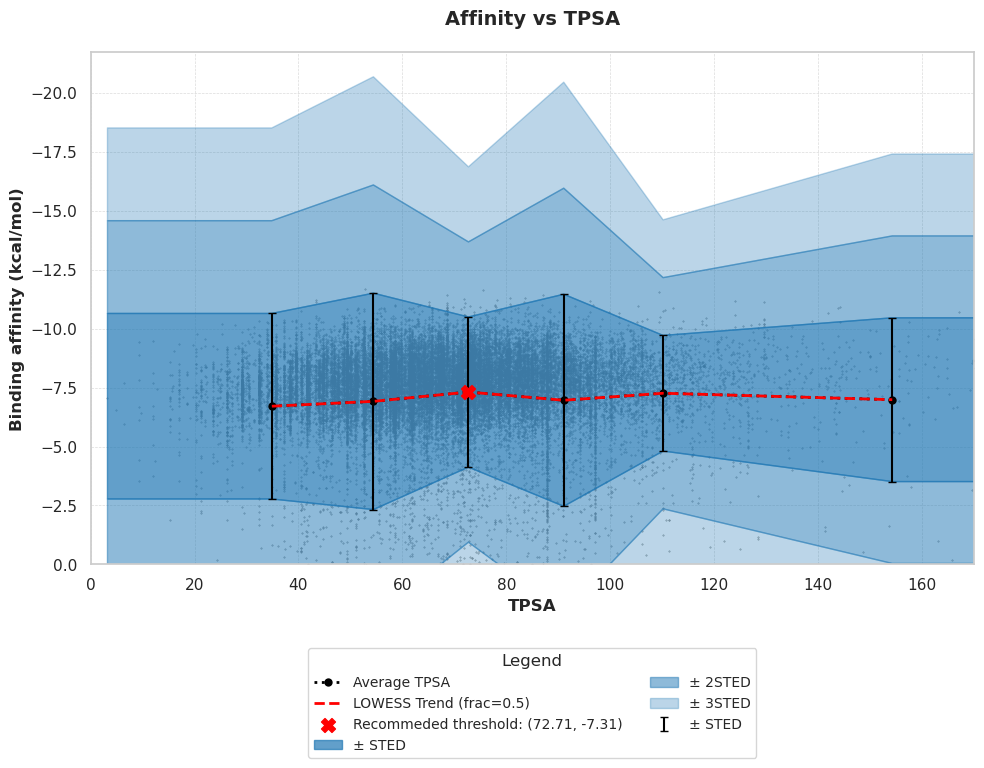

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_Affinity_MW.csv
[ 126.11  215.88  257.52  276.19  296.32  316.25  336.1   356.03  376.22
  395.88  416.    435.87  455.15  475.29  495.03  515.99  545.92  618.94
 1378.52] [-6.6074 -6.6074 -6.7604 -6.9059 -7.146  -7.0152 -7.2403 -7.3154 -7.1603
 -7.1254 -7.1318 -6.9393 -7.1436 -7.1751 -6.9813 -6.4548 -6.0484 -6.2848
 -6.2848] [1.9821 1.9821 1.0987 1.8842 1.6352 3.8644 3.0226 2.7959 4.4857 3.8396
 4.6953 5.2892 4.7603 3.9329 4.6579 5.4835 6.2175 4.8317 4.8317]


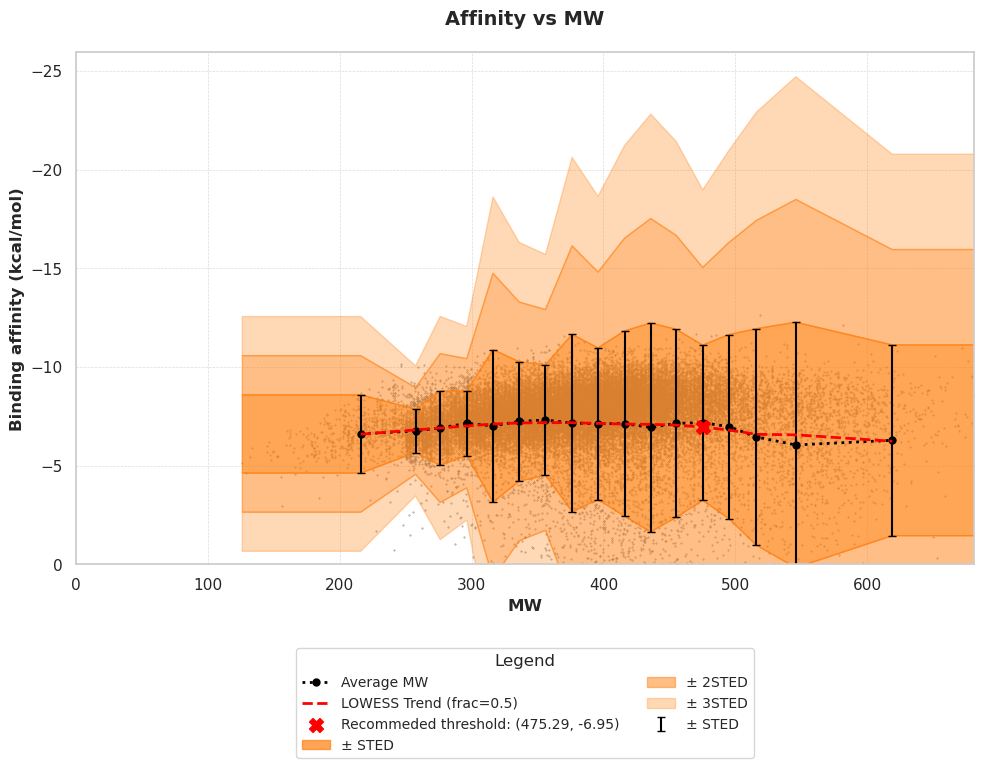

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_Affinity_HBD.csv
[ 0.    1.29  3.4  14.  ] [-7.0639 -7.0639 -7.3562 -7.3562] [3.8762 3.8762 2.9724 2.9724]


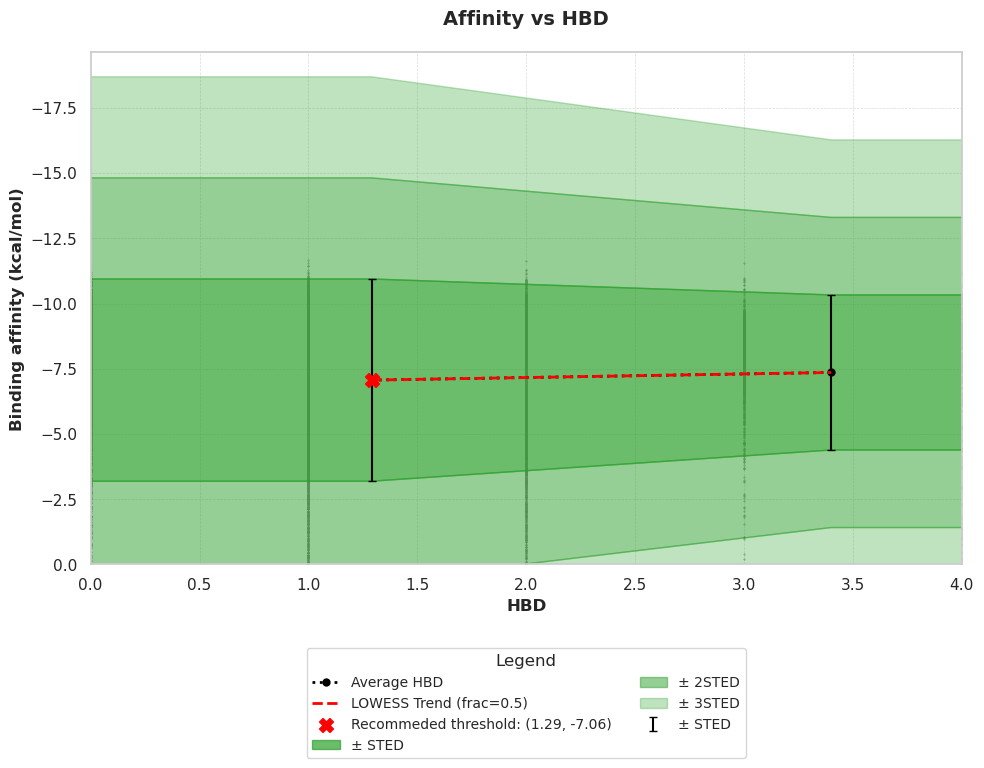

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_Affinity_HBA.csv
[ 0.    1.88  3.    4.    5.    6.    7.    8.   10.48 27.  ] [-6.8823 -6.8823 -6.8257 -6.9789 -7.2374 -7.1878 -7.3312 -7.2922 -7.0991
 -7.0991] [4.0696 4.0696 4.5797 4.3839 3.5911 3.4501 2.4301 2.1113 2.7318 2.7318]


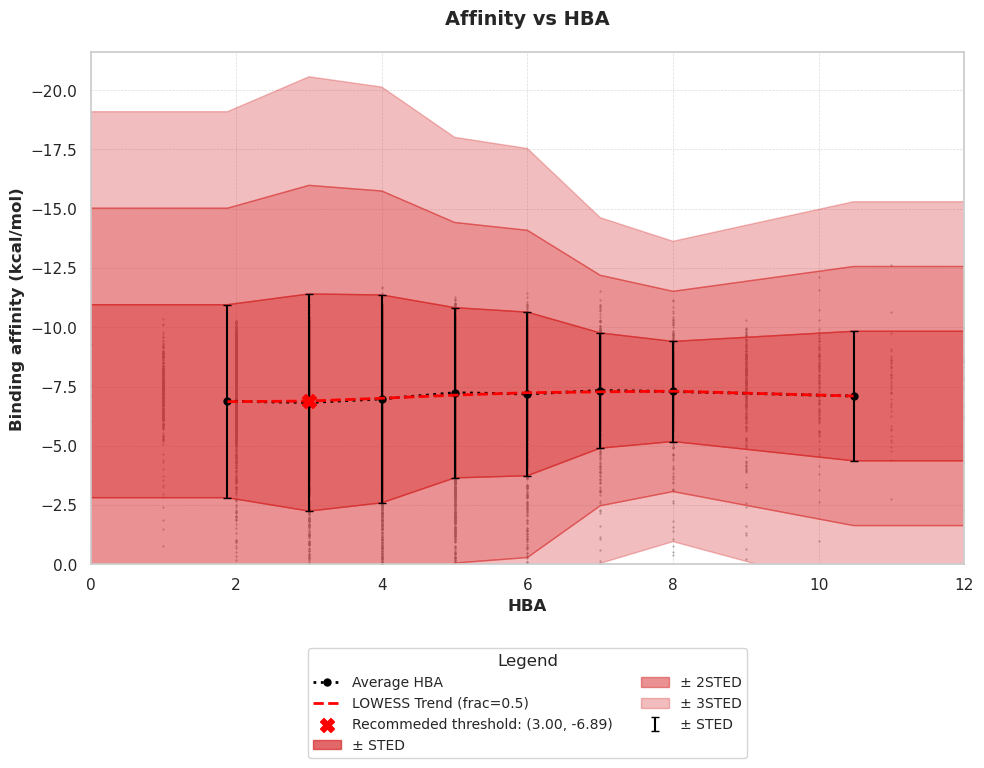

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_Affinity_logP.csv
[-3.15  0.2   1.41  2.39  3.35  4.33  5.27  6.68 14.42] [-6.879  -6.879  -7.0617 -7.1659 -7.1962 -7.1517 -6.7389 -6.1788 -6.1788] [3.0459 3.0459 1.976  2.7969 3.6189 4.2193 6.1235 6.9267 6.9267]


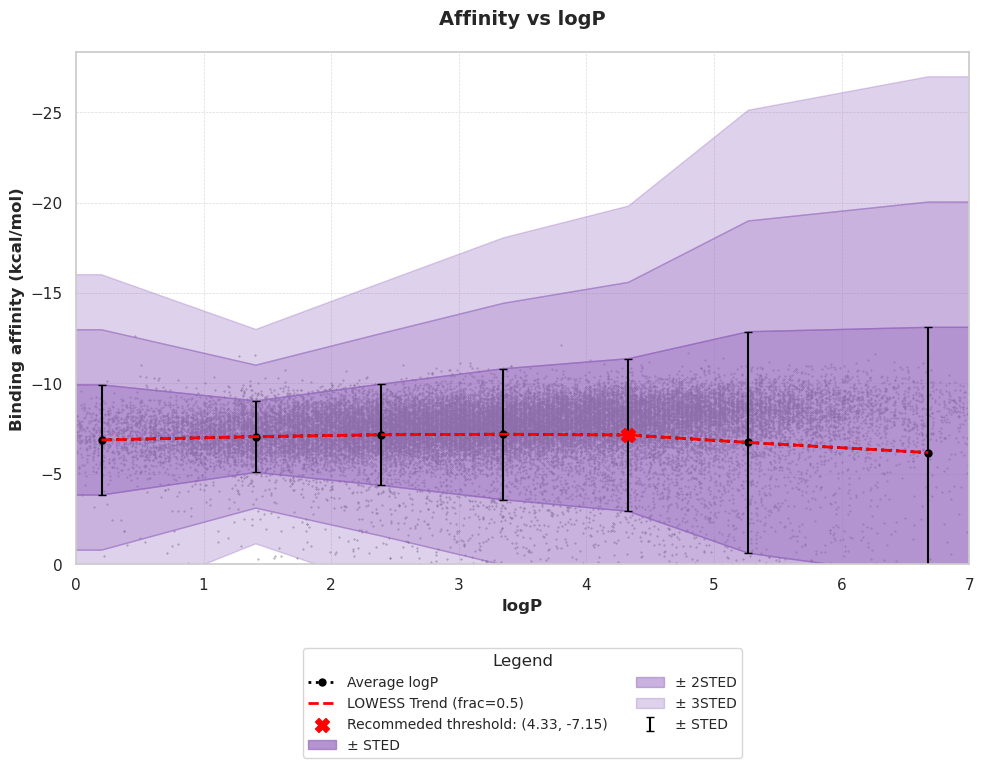

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_Affinity_NumHeavyAtoms.csv
[ 9.   15.63 18.   19.   20.   21.   22.   23.   24.   25.   26.   27.
 28.   29.   30.   31.   32.   33.   34.   35.   36.   37.44 39.48 44.24
 97.  ] [-6.4423 -6.4423 -6.6023 -6.8594 -6.9474 -7.1046 -7.1119 -7.1106 -7.2472
 -7.282  -7.2399 -7.2844 -7.0789 -7.0433 -6.9211 -7.0517 -7.1081 -7.2822
 -7.3995 -7.1579 -6.6376 -6.6481 -5.7288 -6.3544 -6.3544] [1.7233 1.7233 1.4431 1.1372 2.0653 1.3498 2.6089 3.4115 2.8719 2.7507
 3.6442 2.8798 5.1398 3.846  5.2783 4.8605 5.3978 4.8971 3.5648 4.5789
 5.4321 5.6237 6.6057 4.8686 4.8686]


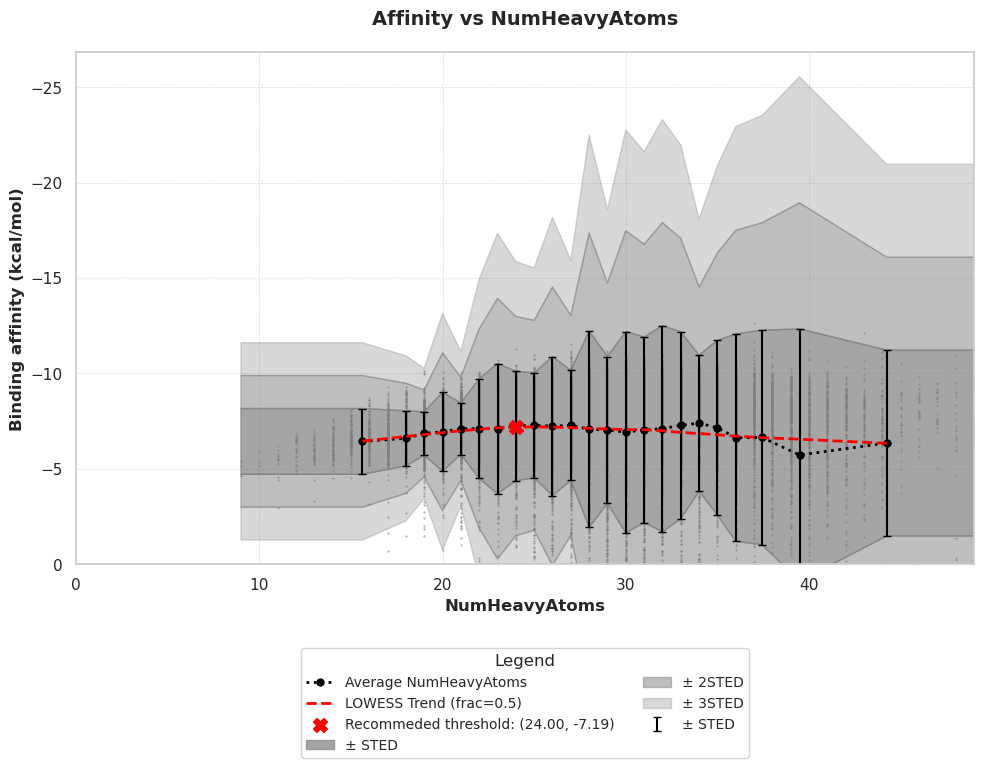

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_Affinity_NumRotatableBonds.csv
[ 0.    1.76  3.    4.    5.    6.    7.    8.    9.   12.06 38.  ] [-4.9465 -4.9465 -6.7863 -7.0206 -7.2693 -7.4731 -7.4657 -7.5878 -7.4518
 -7.2361 -7.2361] [8.4285 8.4285 4.0438 3.5061 3.6224 2.527  2.7396 2.3906 1.5352 1.7918
 1.7918]


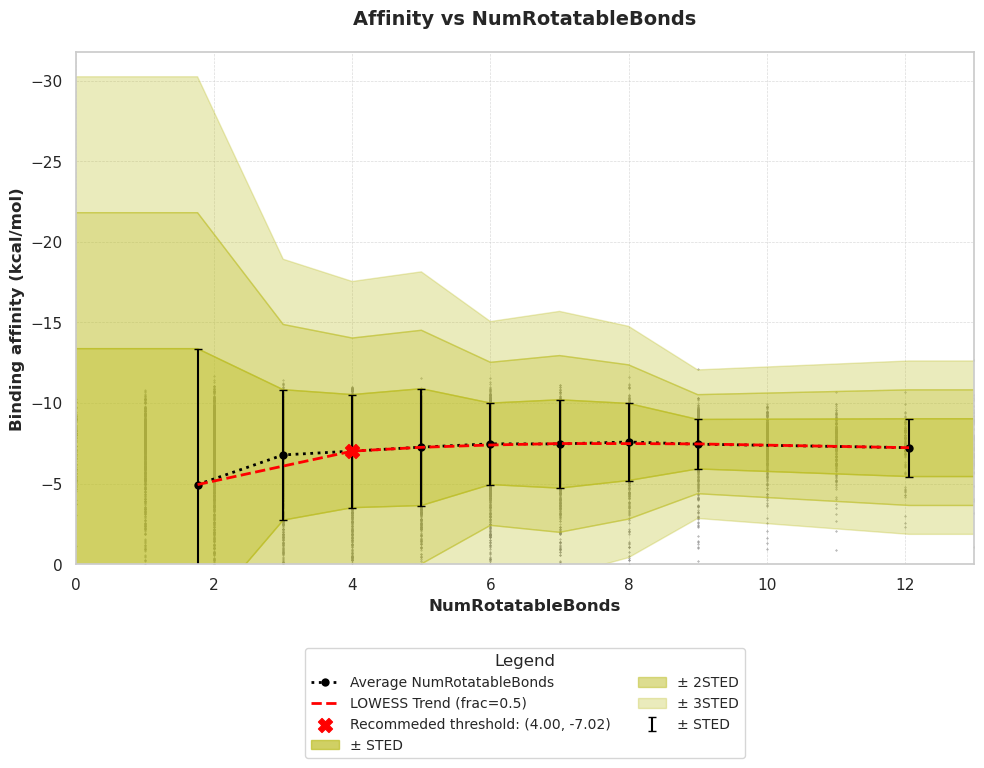

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_Affinity_Solvation_rank1.csv
[  2.4   23.14  29.68  35.25  40.22  44.84  49.95  54.92  59.86  64.9
  69.87  74.85  79.89  84.92  89.8   94.88  99.78 104.75 109.89 114.83
 119.73 127.08 136.98 151.35 201.85 529.36] [-6.3625 -6.3625 -6.324  -6.0241 -6.9521 -6.798  -6.8172 -6.8816 -7.1405
 -7.1132 -7.1948 -7.1369 -7.1743 -6.8109 -7.07   -7.2884 -7.4567 -7.3932
 -7.0162 -7.2046 -7.2375 -7.5221 -7.4893 -7.3662 -7.1551 -7.1551] [4.8509 4.8509 4.6332 7.1024 3.3191 5.5055 4.2544 5.5767 3.359  3.3479
 3.6328 3.4901 2.8815 5.4524 4.0876 2.9994 2.4817 2.1521 4.1635 3.1208
 3.1838 2.5647 2.659  3.4646 2.6407 2.6407]


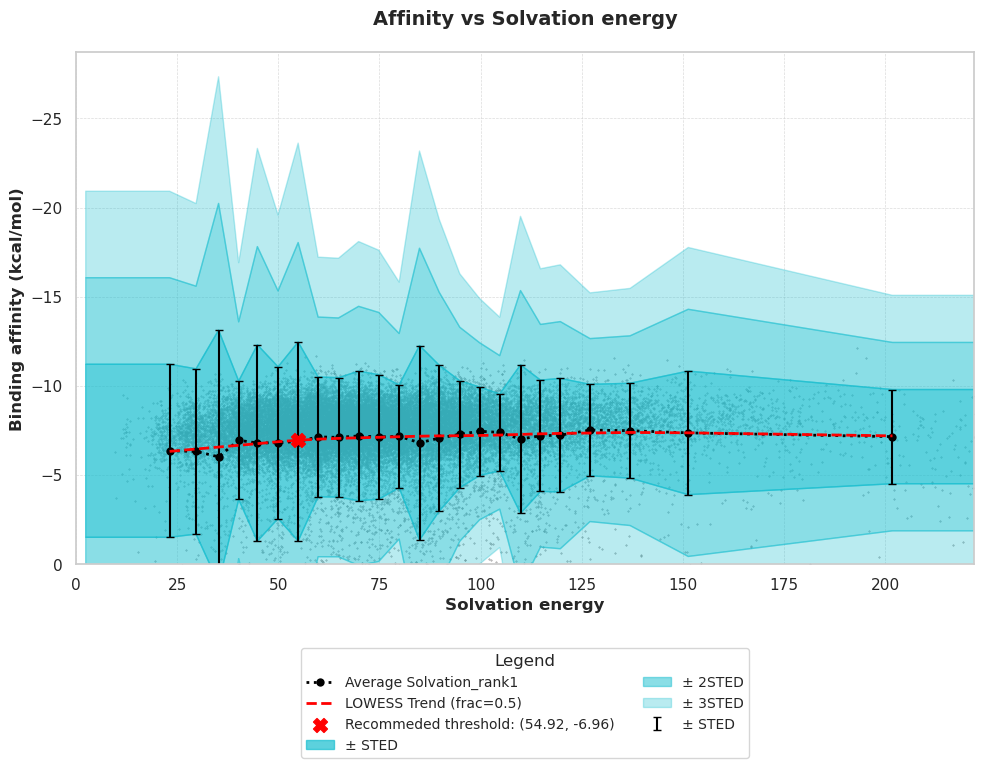

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_CNNaffinity_TPSA.csv
[  3.24  34.87  54.42  72.71  91.05 110.17 154.27 412.38] [5.7529 5.7529 6.1055 6.2986 6.4775 6.4011 6.2498 6.2498] [0.7616 0.7616 0.6737 0.6459 0.6643 0.6878 0.7692 0.7692]


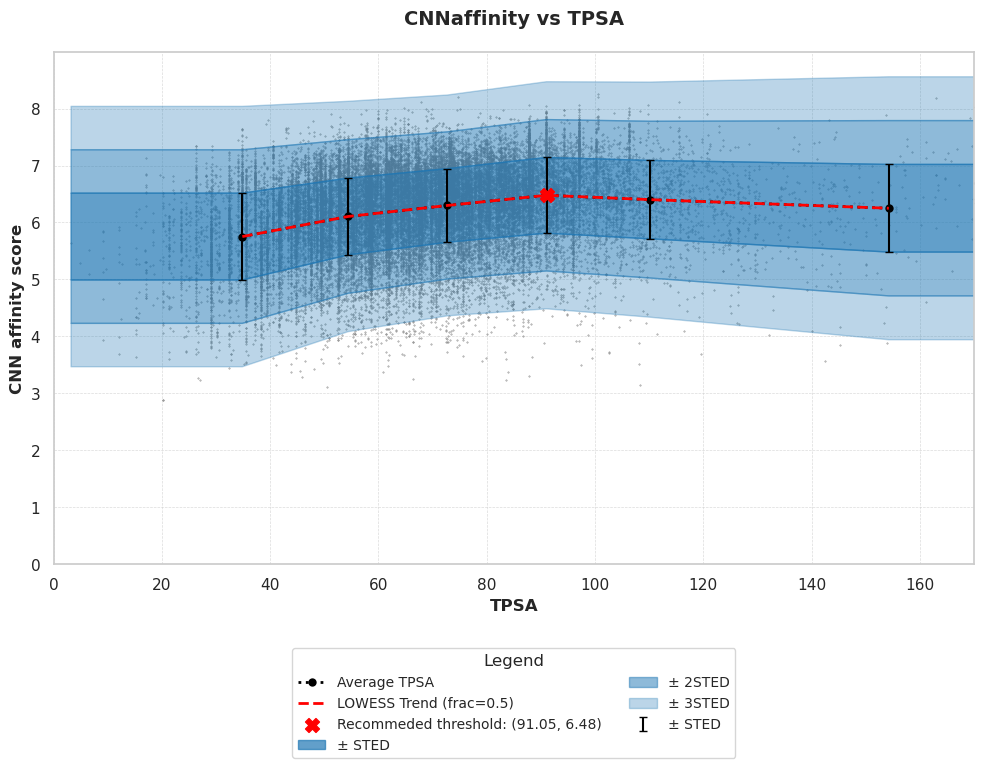

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_CNNaffinity_MW.csv
[ 126.11  215.88  257.52  276.19  296.32  316.25  336.1   356.03  376.22
  395.88  416.    435.87  455.15  475.29  495.03  515.99  545.92  618.94
 1378.52] [4.6342 4.6342 5.2103 5.4138 5.675  5.8326 6.0128 6.155  6.2809 6.3526
 6.463  6.5414 6.613  6.6323 6.7274 6.7872 6.9121 6.9918 6.9918] [0.518  0.518  0.5862 0.5801 0.5723 0.5508 0.5362 0.5254 0.5143 0.5253
 0.5114 0.5226 0.5387 0.5739 0.5672 0.602  0.5572 0.6055 0.6055]


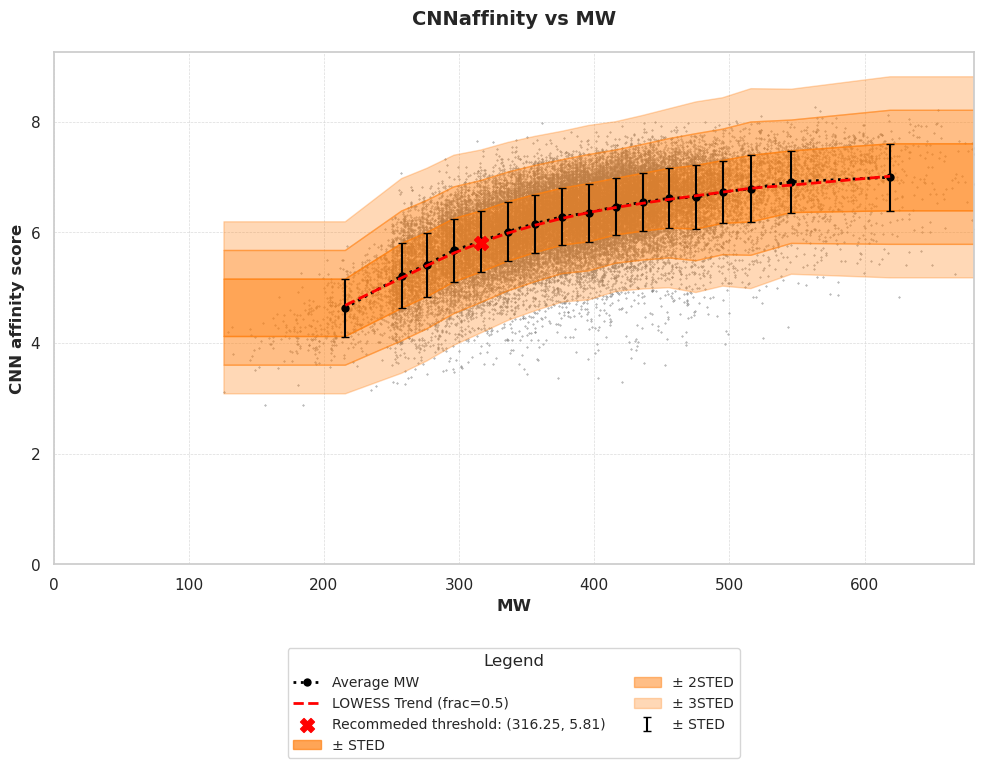

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_CNNaffinity_HBD.csv
[ 0.    1.29  3.4  14.  ] [6.2292 6.2292 6.2654 6.2654] [0.696  0.696  0.7803 0.7803]


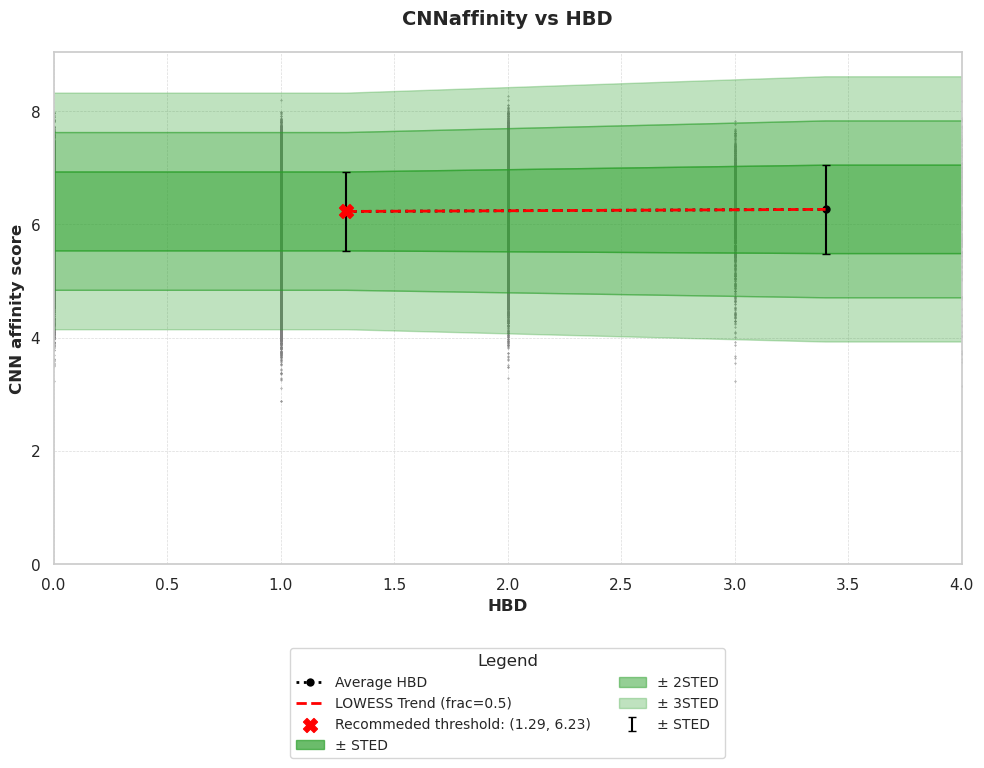

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_CNNaffinity_HBA.csv
[ 0.    1.88  3.    4.    5.    6.    7.    8.   10.48 27.  ] [5.7645 5.7645 6.     6.2145 6.4056 6.3898 6.4151 6.3513 6.3714 6.3714] [0.6843 0.6843 0.675  0.6815 0.6673 0.6801 0.6306 0.6205 0.6678 0.6678]


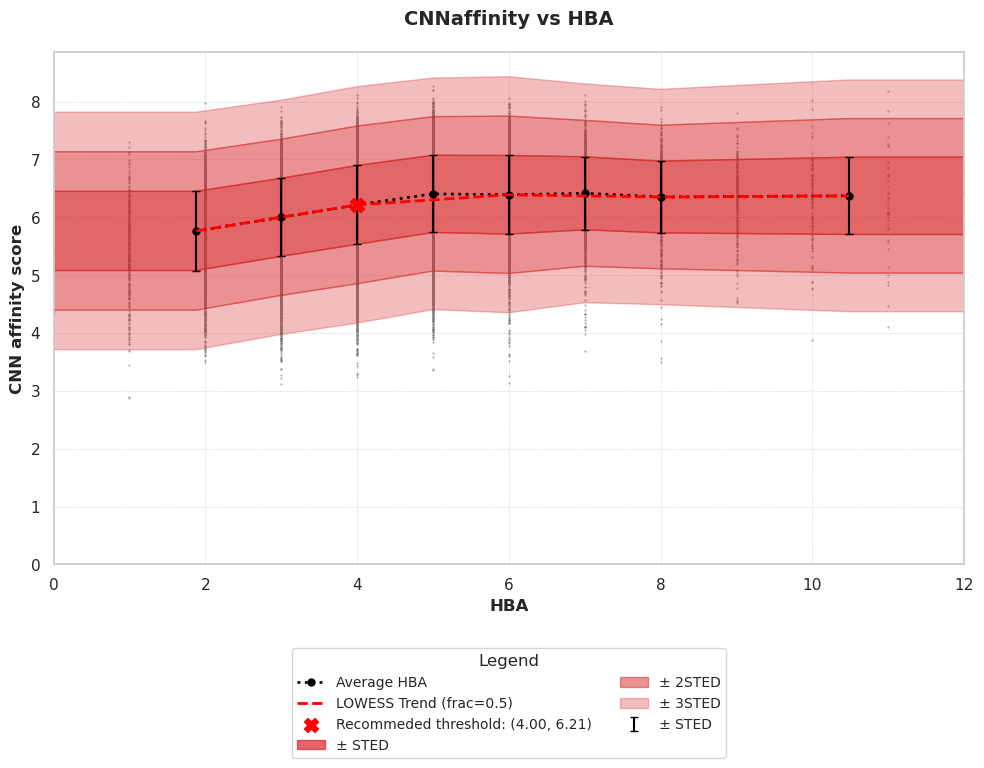

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_CNNaffinity_logP.csv
[-3.15  0.2   1.41  2.39  3.35  4.33  5.27  6.68 14.42] [5.7763 5.7763 5.9111 6.0261 6.1959 6.4434 6.55   6.6292 6.6292] [0.7191 0.7191 0.7288 0.6951 0.6791 0.6088 0.5624 0.5514 0.5514]


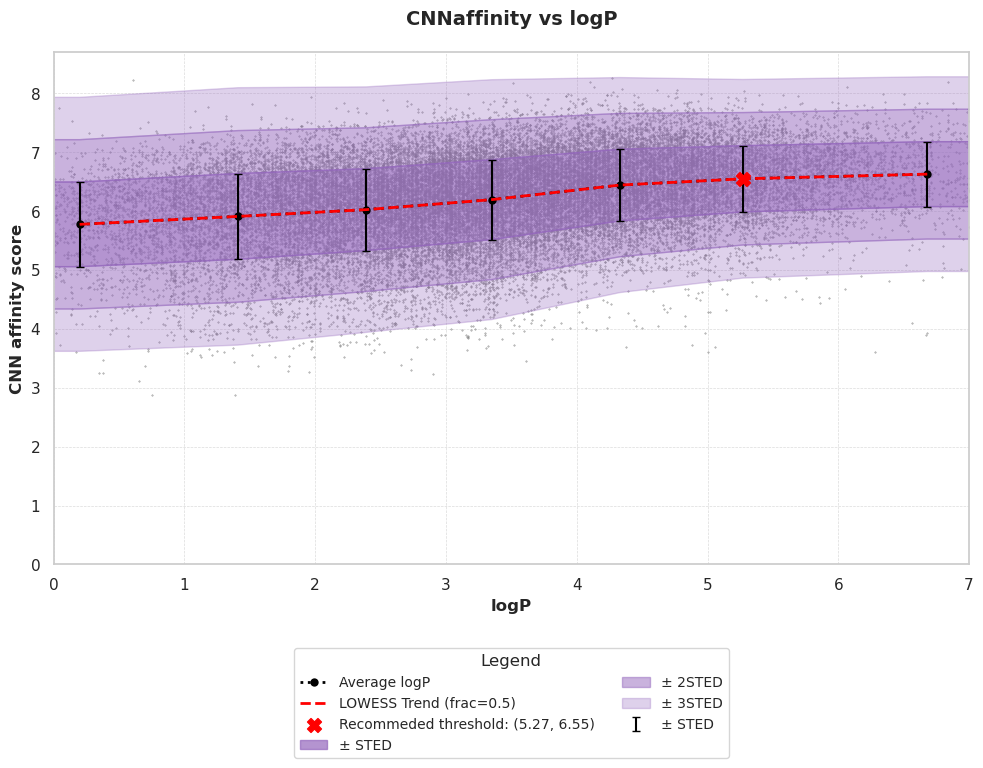

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_CNNaffinity_NumHeavyAtoms.csv
[ 9.   15.63 18.   19.   20.   21.   22.   23.   24.   25.   26.   27.
 28.   29.   30.   31.   32.   33.   34.   35.   36.   37.44 39.48 44.24
 97.  ] [4.664  4.664  5.105  5.3427 5.4843 5.611  5.782  5.8907 6.0067 6.1106
 6.1978 6.2653 6.3509 6.4027 6.4618 6.5482 6.5851 6.6191 6.6864 6.7346
 6.7514 6.83   6.9342 7.0262 7.0262] [0.5312 0.5312 0.5592 0.5616 0.5529 0.5739 0.5421 0.5267 0.5156 0.5101
 0.5227 0.5228 0.4936 0.5041 0.5003 0.5159 0.5259 0.5396 0.5797 0.5221
 0.5795 0.5724 0.5485 0.6052 0.6052]


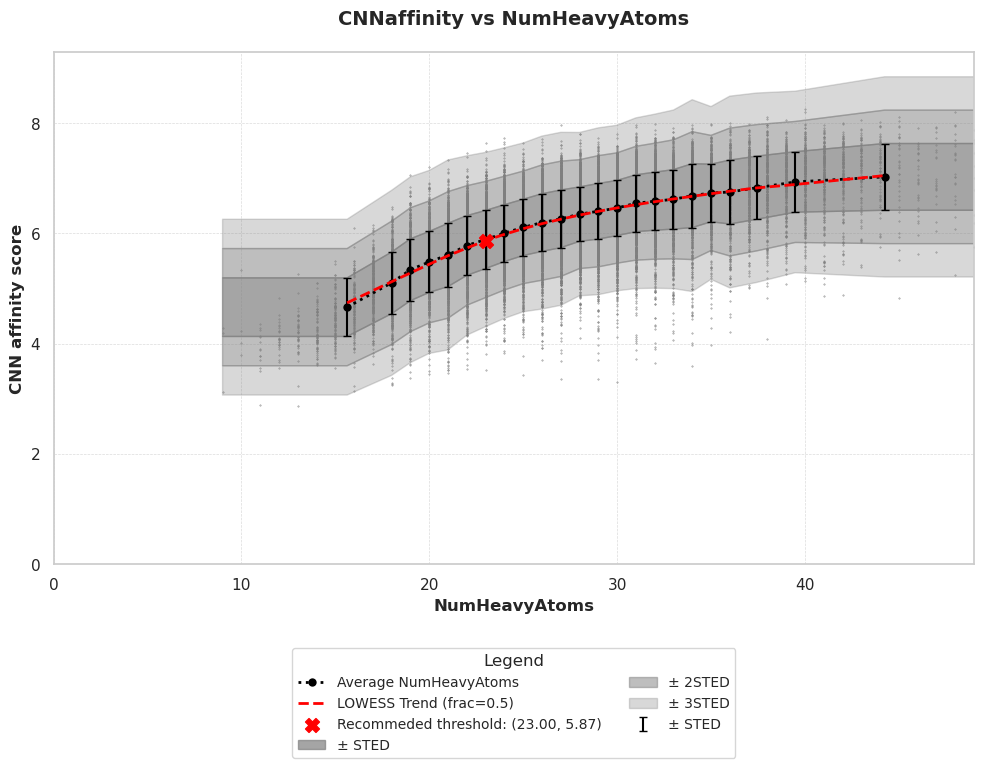

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_CNNaffinity_NumRotatableBonds.csv
[ 0.    1.76  3.    4.    5.    6.    7.    8.    9.   12.06 38.  ] [5.9632 5.9632 6.0282 6.1155 6.1951 6.2859 6.3709 6.4329 6.5044 6.4751
 6.4751] [0.7486 0.7486 0.7009 0.6869 0.6747 0.6703 0.661  0.6533 0.685  0.7202
 0.7202]


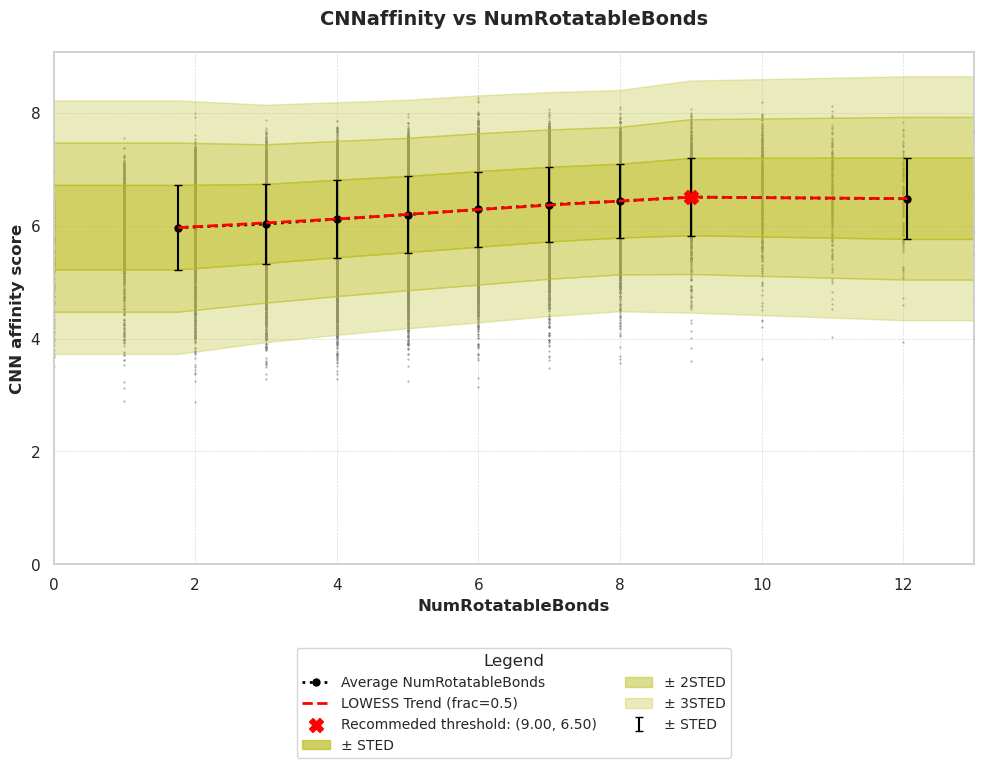

/tmp/ipykernel_1235358/3775061491.py:38: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df_scatter = pd.read_csv(input_csv)
/tmp/ipykernel_1235358/3775061491.py:49: DtypeWarning: Columns (86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


Saved binned statistics to: /liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_CNNaffinity_Solvation_rank1.csv
[  2.4   23.14  29.68  35.25  40.22  44.84  49.95  54.92  59.86  64.9
  69.87  74.85  79.89  84.92  89.8   94.88  99.78 104.75 109.89 114.83
 119.73 127.08 136.98 151.35 201.85 529.36] [5.6432 5.6432 5.9892 6.0678 6.0044 6.1163 6.1342 6.1947 6.1977 6.2008
 6.2329 6.21   6.2109 6.3283 6.3145 6.3479 6.2916 6.2967 6.2988 6.4217
 6.3413 6.3059 6.2994 6.2637 6.2942 6.2942] [0.7219 0.7219 0.6893 0.771  0.687  0.6648 0.7197 0.7059 0.6779 0.6791
 0.6857 0.6909 0.6748 0.6885 0.6796 0.7397 0.6902 0.6872 0.717  0.7224
 0.6792 0.6857 0.6457 0.7008 0.728  0.728 ]


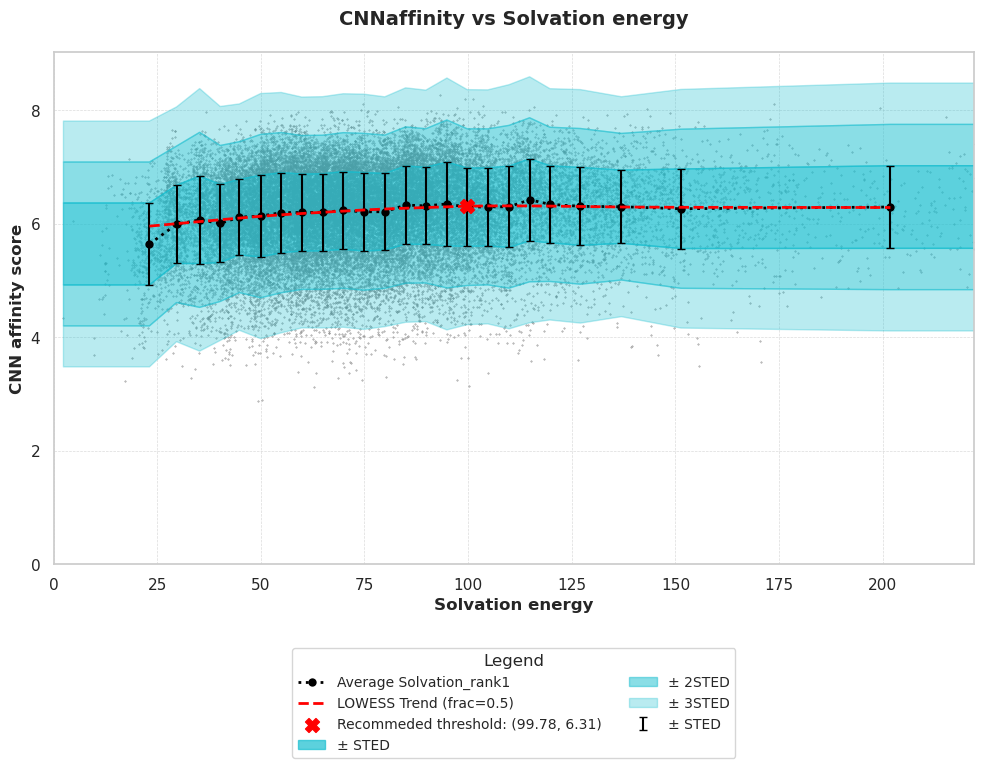

In [19]:
import os
import glob
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
from joblib import Parallel, delayed

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np
import pandas as pd
import numpy as np

# === CONFIG ===
input_csv    = "/liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_properties_score.csv"
min_bin_size = 500
metrics = ('TPSA','MW','HBD','HBA','logP','NumHeavyAtoms','NumRotatableBonds','Solvation_rank1')
#metrics = ('TPSA','MW','HBD','HBA','logP','NumHeavyAtoms','NumRotatableBonds','Charge','Solvation_rank1')

palette  = sns.color_palette('tab10', n_colors=len(metrics))
custom_colors = [
    '#1f77b4',  # TPSA
    '#ff7f0e',  # MW
    '#2ca02c',  # HBD
    '#d62728',  # HBA
    '#9467bd',  # logP
    '#7f7f7f',  # NumHeavyAtoms
    '#bcbd22',  # NumRotatableBonds
    '#17becf',  # Charge
    '#aec7e8',  # Solvation_rank1
]
color_map = dict(zip(metrics, custom_colors))
scores = ('Affinity','CNNaffinity')
for score in scores:
    for metric in metrics:
        df_scatter = pd.read_csv(input_csv)
        #if metric in ('HBD','HBA','logP','NumHeavyAtoms','NumRotatableBonds','Charge'):
        if metric in ('HBD','HBA','logP','NumHeavyAtoms','NumRotatableBonds'):
            bin_width    = 1 
        elif metric in ('Solvation_rank1'):
            bin_width    = 5
        elif metric in ('TPSA','MW'):
            df_scatter = df_scatter[df_scatter[f'{metric}'] != 0]
            bin_width    = 20
        # === STEP 1: Load ===
        output_csv   = f"/liu1/Son/Projects/TYK2/result_gnina/all/TYK2/Confidence_score/TYK2_NCI_final_binned_{score}_{metric}.csv"
        df = pd.read_csv(input_csv)
        df = df[['Compounds', f'{metric}', f'{score}_rank1']].dropna()
        df = df[df[f'{metric}'] != 0]

        # === STEP 2: Define MW bins of width bin_width ===
        mw_min = df[f'{metric}'].min()
        mw_max = df[f'{metric}'].max()
        # Create bin edges [mw_min, mw_min+bin_width, ..., up to >= mw_max]
        edges = np.arange(start=mw_min, stop=mw_max + bin_width, step=bin_width)
        labels = [f"{int(edges[i])}-{int(edges[i+1])}" for i in range(len(edges)-1)]
        df[f'{metric}_bin'] = pd.cut(df[f'{metric}'], bins=edges, labels=labels, include_lowest=True)

        # Group into initial bins
        initial_bins = [group for _, group in df.groupby(f'{metric}_bin')]

        # === STEP 3: Merge small bins ===
        merged_bins = []
        current = initial_bins[0].copy()

        for nxt in initial_bins[1:]:
            # If current bin too small, merge with next
            if len(current) < min_bin_size:
                current = pd.concat([current, nxt], ignore_index=True)
            else:
                merged_bins.append(current)
                current = nxt.copy()

        # Append last
        if not current.empty:
            if len(current) < min_bin_size and merged_bins:
                # merge leftover small bin into last merged
                merged_bins[-1] = pd.concat([merged_bins[-1], current], ignore_index=True)
            else:
                merged_bins.append(current)

        # === STEP 4: Compute statistics ===
        summary = []
        for bin_df in merged_bins:
            low = bin_df[f'{metric}'].min()
            high = bin_df[f'{metric}'].max()
            summary.append({
                'BinRange': f"{low:.2f}-{high:.2f}",
                'BinSize': len(bin_df),
                f'Avg{metric}': round(bin_df[f'{metric}'].mean(), 2),
                f'Avg{score}': round(bin_df[f'{score}_rank1'].mean(), 4),
                f'{score}STD': round(bin_df[f'{score}_rank1'].std(), 4),
                f'Max{score}': round(bin_df[f'{score}_rank1'].max(), 4),
                f'Min{score}': round(bin_df[f'{score}_rank1'].min(), 4),
            })

        summary_df = pd.DataFrame(summary)
        summary_df.to_csv(output_csv, index=False)
        print(f"Saved binned statistics to: {output_csv}")

        # Set Seaborn style

        sns.set_theme(style="whitegrid")

        # Load the CSV file

        df = pd.read_csv(output_csv)
        # Extract columns
        x = df[f'Avg{metric}']
        y = df[f'Avg{score}']
        error = df[f'{score}STD']

        # Create figure and axis
        fig, ax = plt.subplots(figsize=(10, 8))
        plt.scatter(df_scatter[f'{metric}'],df_scatter[f'{score}_rank1'], marker='.', s=0.5, color='gray')
        # Line plot with markers
        if score == 'Affinity':
            label_y = 'Binding affinity (kcal/mol)'
        if score == 'CNNaffinity':
            label_y = 'CNN affinity score'
        sns.lineplot(
            x=x, y=y, ax=ax,
            color='black',
            marker='o',
            markeredgecolor="none",
            markersize=6,
            linewidth=2,
            linestyle='dotted',
            label=f'Average {metric}'
        )

        # Add error bars
        ax.errorbar(
            x=x, y=y, yerr=error,
            fmt='none',
            ecolor='black',
            elinewidth=1.5,
            capsize=3,
            capthick=1,
            label='± STED'
        )

        # LOWESS smoothing
        frac = 0.5  # Fraction of data to use for smoothing
        lowess_smoothed = lowess(y, x, frac=frac)

        # Extract smoothed data
        x_smooth, y_smooth = lowess_smoothed[:, 0], lowess_smoothed[:, 1]

        # Plot LOWESS trendline
        ax.plot(x_smooth, y_smooth, color='red', linewidth=2, linestyle='--', label=f'LOWESS Trend (frac={frac})')

        # Compute curvature for the elbow point
        dy = np.gradient(y_smooth, x_smooth)
        d2y = np.gradient(dy, x_smooth)
        curvature = np.abs(d2y) / (1 + dy ** 2) ** 1.5

        # Find the elbow point
        elbow_idx = np.argmax(curvature)
        elbow_x, elbow_y = x_smooth[elbow_idx], y_smooth[elbow_idx]
        elbow_label = f'Recommeded threshold: ({elbow_x:.2f}, {elbow_y:.2f})'
        # Plot elbow point
        ax.scatter([elbow_x], [elbow_y], s=100, color='red', marker='X', label=elbow_label, zorder=10)

        # Calculate axis limits padding
        #x_range = x.max() - x.min()
        #x_max_extended = x.max() + 0.20 * x_range
        x_max_extended = df_scatter[f'{metric}'].max()
        x_min_extended = df_scatter[f'{metric}'].min()
        x_max = x.max()
        x_min = x.min()
        y_max_extended = df[df[f'Avg{metric}'] == x_max][f'Avg{score}'].values[0]
        y_min_extended = df[df[f'Avg{metric}'] == x_min][f'Avg{score}'].values[0]
        error_max_extended = df[df[f'Avg{metric}'] == x_max][f'{score}STD'].values[0]
        error_min_extended = df[df[f'Avg{metric}'] == x_min][f'{score}STD'].values[0]

        # Extend x, y, and error arrays
        x = np.append(x, x_max_extended)
        y = np.append(y, y_max_extended)
        error = np.append(error, error_max_extended)

        x = np.append(x_min_extended,x)
        y = np.append(y_min_extended,y)
        error = np.append(error_min_extended,error)


        y_min_limit, y_max_limit = (y - 3 * error).min(),(y + 3 * error).max()
    
        print(x,y,error)

        # Shaded regions for uncertainty
        mcolor = color_map[metric]
        ax.fill_between(x, y - error, y + error, color=mcolor, alpha=0.7, label='± STED')
        ax.fill_between(x, y + error, y + 2 * error, color=mcolor, alpha=0.5, label='± 2STED')
        ax.fill_between(x, y - error, y - 2 * error, color=mcolor, alpha=0.5)
        ax.fill_between(x, y + 2 * error, y + 3 * error, color=mcolor, alpha=0.3, label='± 3STED')
        ax.fill_between(x, y - 2 * error, y - 3 * error, color=mcolor, alpha=0.3)

        if x_min >= 0:
            x_min_limit = 0
        else:
            x_min_limit = round(x_min * 0.2,0)
        if x_max < (x.max() * 0.7):
            x_max_limit = round(x_max * 1.1,0)
        

        if score == 'CNNaffinity':
            ax.set(xlim=(x_min_limit, x_max_limit), ylim=(0, y_max_limit*1.05))
        else:
            ax.set(xlim=(x_min_limit, x_max_limit), ylim=(y_min_limit*1.05, 0))
            ax.invert_yaxis()

        # Configure labels and title
        if metric == 'Solvation_rank1':
            label_x = "Solvation energy"
        else: 
            label_x = metric
        ax.set_xlabel(label_x, fontsize=12, fontweight='bold')
        ax.set_ylabel(label_y, fontsize=12, fontweight='bold')
        ax.set_title(f'{score} vs {label_x}', fontsize=14, pad=20, fontweight='bold')

        # Customize grid and legend
        ax.grid(visible=True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
        ax.legend(
            title='Legend',
            title_fontsize=12,
            fontsize=10,
            ncol=2,
            loc='upper center',
            bbox_to_anchor=(0.5, -0.15)
        )

        # Adjust layout and show plot
        plt.tight_layout()
        plt.savefig(f"/liu1/Son/Projects/TYK2/result_gnina/all/Visualization/{score}_{metric}", dpi=300, bbox_inches='tight')
        plt.show()